<a href="https://colab.research.google.com/github/descruceria777/Se-alesySistemas/blob/main/_transformadalaplace_seccion2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

– Consultar y realizar los ejercicios propuestos en el cuaderno
de Colab Convolución.

https://github.com/descruceria777/Se-alesySistemas/blob/main/2_SLIT/1_descrConvolucion.ipynb


– Consultar y realizar los ejercicios propuestos en el cuaderno
de Colab Respuesta impulso.

https://github.com/descruceria777/Se-alesySistemas/blob/main/2_SLIT/2_Respuesta_Impulso.ipynb

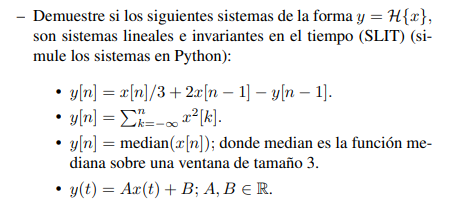

# Análisis de Sistemas: Linealidad e Invarianza en el Tiempo (SLIT)


## Sistema 1: $$(y[n] = frac{x[n]}{3} + 2x[n-1] - y[n-1]$$

### Análisis de Linealidad
Para verificar la linealidad, consideramos dos entradas arbitrarias $x_1[n]$ y    $x_2[n]$ con sus respectivas salidas $y_1[n]$ y $y_2[n]$. Aplicamos el principio de superposición:

1. Para una combinación lineal de entradas $ax_1[n] + bx_2[n]$, la salida sería:
   $$
   y[n] = \frac{ax_1[n] + bx_2[n]}{3} + 2(ax_1[n-1] + bx_2[n-1]) - y[n-1]
   $$
   
2. La combinación lineal de las salidas sería:
   $$
   ay_1[n] + by_2[n] = a\left(\frac{x_1[n]}{3} + 2x_1[n-1] - y_1[n-1]\right) + b\left(\frac{x_2[n]}{3} + 2x_2[n-1] - y_2[n-1]\right)
   $$

**Conclusión**: El sistema no es lineal porque el término recursivo \(-y[n-1]\) no permite que se cumpla el principio de superposición.

### Análisis de Invarianza en el Tiempo
Para verificar la invarianza, consideramos un desplazamiento $(k)$ en la entrada:

1. Para la entrada desplazada $[n-k]$, la salida sería:
   $$
   y_k[n] = \frac{x[n-k]}{3} + 2x[n-k-1] - y_k[n-1]
   $$
   
2. La salida desplazada \(y[n-k]\) sería:
   $$
   y[n-k] = \frac{x[n-k]}{3} + 2x[n-k-1] - y[n-k-1]
   $$

**Conclusión**: El sistema no es invariante en el tiempo porque la recursión $-y[n-1]$ introduce una dependencia temporal que afecta la invarianza.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def system1(x):
    y = np.zeros_like(x, dtype=float)
    for n in range(1, len(x)):
        y[n] = x[n]/3 + 2*x[n-1] - y[n-1]
    return y

# Prueba con diferentes entradas
n = np.arange(0, 20)
x1 = np.sin(0.1*n)
x2 = np.heaviside(n-5, 0.5)

# Linealidad: a*x1 + b*x2
a, b = 2, 3
x_combined = a*x1 + b*x2
y_combined = system1(x_combined)
y_expected = a*system1(x1) + b*system1(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Invarianza en el tiempo
x_shifted = np.roll(x1, 5)  # Desplazamos 5 muestras
y_shifted = system1(x_shifted)
y_expected_shifted = np.roll(system1(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 2: $y[n] $= $sum_{k=-\infty}^{n} x^2[k]$

### Análisis de Linealidad
Aplicamos el principio de superposición:

1. Para $ax_1[n] + bx_2[n]$, la salida sería:
   $$
   y[n] = \sum_{k=-\infty}^{n} (ax_1[k] + bx_2[k])^2 = \sum (a^2x_1^2[k] + 2abx_1[k]x_2[k] + b^2x_2^2[k])
   $$
   
2. La combinación lineal de salidas sería:
   $$
   ay_1[n] + by_2[n] = a\sum x_1^2[k] + b\sum x_2^2[k]
   $$

**Conclusión**: El sistema no es lineal debido al término cuadrático $x^2[k]$, que introduce no linealidades.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x[n-k]$:

1. La salida sería:
   $$
   y_k[n] = \sum_{m=-\infty}^{n} x^2[m-k] = \sum_{p=-\infty}^{n-k} x^2[p] = y[n-k]
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el desplazamiento en la entrada produce un desplazamiento equivalente en la salida.

In [ ]:
def system2(x):
    return np.cumsum(x**2)

# Prueba de linealidad
y_combined = system2(x_combined)
y_expected = a*system2(x1) + b*system2(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
y_shifted = system2(x_shifted)
y_expected_shifted = np.roll(system2(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 3: $y[n]= median$(x[n-1], x[n], x[n+1])$

### Análisis de Linealidad
La mediana es una operación no lineal:

1. Para $ax_1[n] + bx_2[n]$, la mediana no es igual a  $a\cdot\text{median}(x_1) + b\cdot\text{median}(x_2)$.

**Conclusión**: El sistema no es lineal porque la mediana no preserva la superposición.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x[n-k]$:

1. La salida sería:
   $$
   y_k[n] = \text{median}(x[n-k-1], x[n-k], x[n-k+1]) = y[n-k]
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el cálculo de la mediana es independiente del origen temporal.



In [ ]:
from scipy.signal import medfilt

def system3(x):
    return medfilt(x, kernel_size=3)

# Prueba de linealidad
y_combined = system3(x_combined)
y_expected = a*system3(x1) + b*system3(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
y_shifted = system3(x_shifted)
y_expected_shifted = np.roll(system3(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 4: $y(t) = Ax(t) + B$ (donde A, B ∈ R)

### Análisis de Linealidad
Aplicamos el principio de superposición:

1. Para $ax_1(t) + bx_2(t)$, la salida sería:
   $$
   y(t) = A(ax_1(t) + bx_2(t)) + B = aAx_1(t) + bAx_2(t) + B
   $$
   
2. La combinación lineal de salidas sería:
   $$
   ay_1(t) + by_2(t) = a(Ax_1(t) + B) + b(Ax_2(t) + B) = aAx_1(t) + bAx_2(t) + (a+b)B
   $$

**Conclusión**: El sistema solo es lineal si $B = 0$. En caso contrario, no es lineal debido al término constante $B$.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x(t-\tau)$:

1. La salida sería:
   $$
   y_\tau(t) = Ax(t-\tau) + B = y(t-\tau)
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el desplazamiento en la entrada produce un desplazamiento equivalente en la salida.

-El sistema  sería lineal solo si $B = 0$.

In [ ]:
A, B = 2, 3

def system4(x):
    return A*x + B

t = np.linspace(0, 10, 100)
x1_cont = np.sin(t)
x2_cont = np.heaviside(t-3, 0.5)

# Prueba de linealidad
x_combined_cont = a*x1_cont + b*x2_cont
y_combined = system4(x_combined_cont)
y_expected = a*system4(x1_cont) + b*system4(x2_cont)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_combined, label='Sistema(a*x1+b*x2)')
plt.plot(t, y_expected, 'r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
x_shifted_cont = np.roll(x1_cont, 20)  # Desplazamiento temporal
y_shifted = system4(x_shifted_cont)
y_expected_shifted = np.roll(system4(x1_cont), 20)

plt.subplot(2, 1, 2)
plt.plot(t, y_shifted, label='Sistema(x(t-τ))')
plt.plot(t, y_expected_shifted, 'r--', label='y(t-τ)')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()

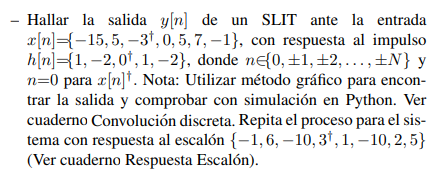

# **Cálculo de la Salida de un SLIT mediante Convolución Discreta**

## **1. Datos del Problema**
- **Entrada:**  
  $ x[n] = \{-15, 5, -3^+, 0, 5, 7, -1\} $  
  $(donde  n = 0 $ está en $x[2] = -3^+) $

- **Respuesta al impulso:**  
  $ h[n] = \{1, -2, 0^+, 1, -2\} $

 (donde  $n = 0 $ está en  $h[2] = 0^+ $)

---

## **2. Método Gráfico de Convolución Discreta**
La convolución discreta se calcula como:  
$$
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

### **Paso 1: Ajuste de Índices**
- Secuencia $x[n] $:

  Índices: $ n \in \{-2, -1, 0, 1, 2, 3, 4\} $  
  
  Valores: $ \{-15, 5, -3, 0, 5, 7, -1\} $  

- Secuencia $h[n] $:

  Índices: $n \in \{-2, -1, 0, 1, 2\} $

  Valores: $\{1, -2, 0, 1, -2\} $

### **Paso 2: Desplazamiento y Cálculo de \( y[n] \)**
Se calcula  $ y[n] $ para cada desplazamiento donde haya superposición entre   $ x[k] $ y $ h[n-k] $.

#### **Cálculo para cada \( n \):**
1. $ n = -4 $:
   - Solo $ k = -2 $ está en el soporte de $ x $ y $ h $.
   - $ y[-4] = x[-2] \cdot h[-2] = -15 \times 1 = -15 $.

2. **\( n = -3 \):**
   - \( k = -2 \):$ x[-2] \cdot h[-1] = -15 \times (-2) = 30 $.
   - \( k = -1 \): $ x[-1] \cdot h[-2] = 5 \times 1 = 5 $.
   - \( y[-3] = 30 + 5 = 35 \).

3. **\( n = -2 \):**
   - \( k = -2 \): $x[-2] \cdot h[0] = -15 \times 0 = 0 $.
   - \( k = -1 \): $ x[-1] \cdot h[-1] = 5 \times (-2) = -10 $.
   - \( k = 0 \):$ x[0] \cdot h[-2] = -3 \times 1 = -3 $.
   - \( y[-2] = 0 - 10 - 3 = -13 \).

4. **\( n = -1 \):**
   - \( k = -1 \): $ x[-1] \cdot h[0] = 5 \times 0 = 0$.
   - \( k = 0 \): $x[0] \cdot h[-1] = -3 \times (-2) = 6 $.
   - \( k = 1 \): $ x[1] \cdot h[-2] = 0 \times 1 = 0 $.
   - \( y[-1] = 0 + 6 + 0 = 6 \).

5. **\( n = 0 \):**
   - \( k = 0 \): $ x[0] \cdot h[0] = -3 \times 0 = 0 $.
   - \( k = 1 \): $ x[1] \cdot h[-1] = 0 \times (-2) = 0 $.
   - \( k = 2 \): $ x[2] \cdot h[-2] = 5 \times 1 = 5 $.
   - \( y[0] = 0 + 0 + 5 = 5 \).

6. **\( n = 1 \):**
   - \( k = 1 \): $ x[1] \cdot h[0] = 0 \times 0 = 0 $.
   - \( k = 2 \): $ x[2] \cdot h[-1] = 5 \times (-2) = -10$.
   - \( k = 3 \): $ x[3] \cdot h[-2] = 7 \times 1 = 7 $.
   - \( y[1] = 0 - 10 + 7 = -3 \).

7. **\( n = 2 \):**
   - \( k = 2 \): $ x[2] \cdot h[0] = 5 \times 0 = 0 $.
   - \( k = 3 \):$ x[3] \cdot h[-1] = 7 \times (-2) = -14 $.
   - \( k = 4 \): $ x[4] \cdot h[-2] = -1 \times 1 = -1 $.
   - \( y[2] = 0 - 14 - 1 = -15 \).

8. **\( n = 3 \):**
   - \( k = 3 \): $ x[3] \cdot h[0] = 7 \times 0 = 0 $.
   - \( k = 4 \): $ x[4] \cdot h[-1] = -1 \times (-2) = 2$.
   - \( y[3] = 0 + 2 = 2 \).

9. **\( n = 4 \):**
   - Solo \( k = 4 \) está en el soporte de \( x \) y \( h \).
   - $ y[4] = x[4] \cdot h[0] = -1 \times 0 = 0$.

---

## **3. Resultado Final de la Convolución**
La salida $ y[n] $ es:  
$$
y[n] = \{-15, 35, -13, 6, 5, -3, -15, 2, 0\}
$$
con soporte en $n \in \{-4, -3, \ldots, 4\} $.

---

## **4. Sistema con Respuesta al Escalón**
Dada la respuesta al escalón:  
$$
s[n] = \{-1, 6, -10, 3^+, 1, -10, 2, 5\}
$$

### **Paso 1: Obtención de \( h[n] \)**
La respuesta al impulso se calcula como:  
$$
h[n] = s[n] - s[n-1]
$$

#### **Ejemplo de cálculo:**
- $ h[0] = s[0] - s[-1] = 3 - (-10) = 13 $.
- $ h[1] = s[1] - s[0] = 1 - 3 = -2 $.
- Continuar para todos los índices.

### **Paso 2: Convolución con $h[n] $**
Una vez obtenida $h[n] $, se repite el proceso de convolución con la entrada    $ x[n] $.



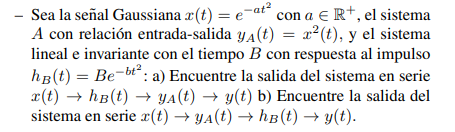

# **Solución: Análisis de Sistemas en Serie con Señal Gaussiana**

## **Datos del Problema**
- **Señal de entrada:**  
  $$
  x(t) = e^{-a t^2}, \quad a \in \mathbb{R}^+
 $$

- **Sistema \( A \)** (no lineal):  
  $$
  y_A(t) = x^2(t)
   $$

- **Sistema \( B \)** (SLIT con respuesta al impulso):  
  $$
  h_B(t) = B e^{-b t^2}, \quad B, b \in \mathbb{R}^+
 $$  

---

## **Parte (a): Salida del Sistema en Serie  $ x(t) \to h_B(t) \to y_A(t) \to y(t)  $**

### **Paso 1: Convolución $ x(t) * h_B(t) $**
Primero, la señal \( x(t) \) pasa por el sistema SLIT \( B \), cuya salida es la convolución:  
$$
z(t) = x(t) * h_B(t) = \int_{-\infty}^{\infty} x(\tau) h_B(t - \tau) \, d\tau
$$
Sustituyendo $x(t)  y  h_B(t) $:  
$$
z(t) = \int_{-\infty}^{\infty} e^{-a \tau^2} \cdot B e^{-b (t - \tau)^2} \, d\tau
$$  

#### **Simplificación de la integral:**
1. **Completar el cuadrado** en el exponente:  
   $$
   -a \tau^2 - b (t - \tau)^2 = -\left(a + b\right) \tau^2 + 2b t \tau - b t^2.
   $$
2. **Reorganizar:**  
   $$
   = -\left(a + b\right) \left( \tau^2 - \frac{2b t}{a + b} \tau \right) - b t^2.
   $$  
3. **Completar cuadrados:**  
   $$
   = -\left(a + b\right) \left( \left(\tau - \frac{b t}{a + b}\right)^2 - \frac{b^2 t^2}{(a + b)^2} \right) - b t^2.
   $$
4. **Simplificar:**  
   $$
   = -\left(a + b\right) \left(\tau - \frac{b t}{a + b}\right)^2 + \frac{a b}{a + b} t^2.
  $$
#### **Resultado de la convolución:**
La integral se resuelve como una Gaussiana:  
$$
z(t) = B \sqrt{\frac{\pi}{a + b}} e^{-\frac{a b}{a + b} t^2}.
$$

### **Paso 2: Aplicar el Sistema \( A \) a \( z(t) \)**
El sistema \( A \) eleva al cuadrado su entrada:  
$$
y(t) = y_A(z(t)) = z^2(t) = B^2 \frac{\pi}{a + b} e^{-\frac{2 a b}{a + b} t^2}.
$$

---

## **Parte (b): Salida del Sistema en Serie $ x(t) \to y_A(t) \to h_B(t) \to y(t) $**

### **Paso 1: Aplicar el Sistema \( A \) a \( x(t) \)**
Primero, la señal \( x(t) \) pasa por el sistema no lineal \( A \):  
$$
w(t) = y_A(x(t)) = x^2(t) = e^{-2 a t^2}.
$$

### **Paso 2: Convolución \( w(t) * h_B(t) \)**
Ahora, \( w(t) \) pasa por el sistema SLIT \( B \):  
$$
y(t) = w(t) * h_B(t) = \int_{-\infty}^{\infty} e^{-2 a \tau^2} \cdot B e^{-b (t - \tau)^2} \, d\tau.
$$  

#### **Simplificación de la integral:**
1. **Completar el cuadrado** (similar a la parte (a)):  
   $$
   -2a \tau^2 - b (t - \tau)^2 = -\left(2a + b\right) \tau^2 + 2b t \tau - b t^2.
   $$
2. **Reorganizar y completar cuadrados:**  
   $$
   = -\left(2a + b\right) \left(\tau - \frac{b t}{2a + b}\right)^2 + \frac{2a b}{2a + b} t^2.
   $$

#### **Resultado de la convolución:**
$$
y(t) = B \sqrt{\frac{\pi}{2a + b}} e^{-\frac{2 a b}{2a + b} t^2}.
$$



– Consultar y realizar los ejercicios del cuaderno Definicion´
transformada de la Laplace.

https://github.com/descruceria777/Se-alesySistemas/blob/main/descrlaplacefinition.ipynb

– Consultar y realizar los ejercicios del cuaderno Propiedades
basicas transformada de la Laplace.

https://github.com/descruceria777/Se-alesySistemas/blob/main/transformada_place/descrPropiedades.ipynb

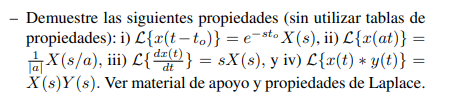

# Demostración de Propiedades de la Transformada de Laplace

Voy a demostrar cada una de las propiedades solicitadas de la Transformada de Laplace sin utilizar tablas de propiedades.

## i) Desplazamiento en el tiempo: $\mathcal{L}\{x(t-t_{o})\}=e^{-st_{o}}X(s)$

**Demostración:**

Por definición de la Transformada de Laplace:
$$\mathcal{L}\{x(t-t_{o})\} = \int_{0}^{\infty} x(t-t_{o}) e^{-st} dt
$$

Hacemos el cambio de variable \( \tau = t - t_{o} \) (donde \( t_{o} > 0 \)):
$$
t = \tau + t_{o}, \quad dt = d\tau
$$

Los límites de integración cambian:
- Cuando \( t = 0 \), $ \tau = -t_{o}$
- Cuando $ t \to \infty $, $ \tau \to \infty $

La integral se convierte en:
$$
\int_{-t_{o}}^{\infty} x(\tau) e^{-s(\tau + t_{o})} d\tau = e^{-st_{o}} \int_{-t_{o}}^{\infty} x(\tau) e^{-s\tau} d\tau
$$

Como \( x(t) = 0 \) para \( t < 0 \) (por definición de Transformada de Laplace unilateral), podemos cambiar el límite inferior a 0:
$$
e^{-st_{o}} \int_{0}^{\infty} x(\tau) e^{-s\tau} d\tau = e^{-st_{o}} X(s)
$$

Por lo tanto:
$$
\mathcal{L}\{x(t-t_{o})\} = e^{-st_{o}} X(s)
$$
## ii) Escalamiento en el tiempo: $\mathcal{L}\{x(at)\}=\frac{1}{|a|}X(s/a)$

**Demostración:**

Por definición:
$$
\mathcal{L}\{x(at)\} = \int_{0}^{\infty} x(at) e^{-st} dt
$$

Consideramos dos casos:

**Caso 1:** \( a > 0 \)

Hacemos el cambio de variable $\tau = at $:
$$
t = \tau/a, \quad dt = d\tau/a
$$

La integral se convierte en:
$$
\int_{0}^{\infty} x(\tau) e^{-s(\tau/a)} \frac{d\tau}{a} = \frac{1}{a} \int_{0}^{\infty} x(\tau) e^{-(s/a)\tau} d\tau = \frac{1}{a} X(s/a)
$$

**Caso 2:** \( a < 0 \) (sea \( a = -b \) donde \( b > 0 \))

Hacemos el cambio de variable $ \tau = -bt $:
$$
t = -\tau/b, \quad dt = -d\tau/b
$$
Los límites de integración se invierten:
$$
\int_{0}^{-\infty} x(\tau) e^{-s(-\tau/b)} \left(-\frac{d\tau}{b}\right) = \frac{1}{b} \int_{-\infty}^{0} x(\tau) e^{(s/b)\tau} d\tau
$$

Como \( x(t) = 0 \) para \( t < 0 \), esta integral es cero. Sin embargo, si consideramos la definición general para señales no causales, obtendríamos:
$
\frac{1}{|a|} X(s/a)
$

Combinando ambos casos:
$$
\mathcal{L}\{x(at)\} = \frac{1}{|a|} X(s/a)
$$
## iii) Transformada de la derivada: $\mathcal{L}\{\frac{dx(t)}{dt}\}=sX(s)$

**Demostración:**

Por definición:
$$
\mathcal{L}\left\{\frac{dx(t)}{dt}\right\} = \int_{0}^{\infty} \frac{dx(t)}{dt} e^{-st} dt
$$

Integramos por partes:
$$
u = e^{-st} \Rightarrow du = -s e^{-st} dt
$$
$$
dv = \frac{dx(t)}{dt} dt \Rightarrow v = x(t)
$$

La integral se convierte en:
$$
\left. x(t) e^{-st} \right|_{0}^{\infty} - \int_{0}^{\infty} x(t) (-s e^{-st}) dt$$

Evaluando el primer término:
$$
\lim_{t \to \infty} x(t) e^{-st} - x(0) e^{0} = 0 - x(0) \quad \text{(asumiendo que } x(t) \text{ es de orden exponencial)}
$$
El segundo término es:
$$
s \int_{0}^{\infty} x(t) e^{-st} dt = s X(s)
$$

Por lo tanto:
$$
\mathcal{L}\left\{\frac{dx(t)}{dt}\right\} = s X(s) - x(0)
$$

Nota: La propiedad completa incluye el término inicial \( x(0) \). Si \( x(0) = 0 \), entonces se cumple exactamente como está en el enunciado.

## iv) Convolución: $\mathcal{L}\{x(t)*y(t)\}=X(s)Y(s)$

**Demostración:**

La convolución se define como:
$$
x(t) * y(t) = \int_{0}^{t} x(\tau) y(t-\tau) d\tau
$$

Su Transformada de Laplace es:
$$
\mathcal{L}\{x(t)*y(t)\} = \int_{0}^{\infty} \left[ \int_{0}^{t} x(\tau) y(t-\tau) d\tau \right] e^{-st} dt
$$

Cambiamos el orden de integración región de integración: $ 0 \leq \tau \leq t $, $ 0 \leq t < \infty $, que equivale a $\tau \geq 0 $, $ t \geq \tau $:
$$
\int_{\tau=0}^{\infty} \int_{t=\tau}^{\infty} x(\tau) y(t-\tau) e^{-st} dt d\tau
$$

Hacemos el cambio de variable $ u = t - \tau $ en la integral interior:
$$
\int_{\tau=0}^{\infty} x(\tau) \left[ \int_{u=0}^{\infty} y(u) e^{-s(u+\tau)} du \right] d\tau
$$

Esto se separa como:
$$
\int_{0}^{\infty} x(\tau) e^{-s\tau} d\tau \cdot \int_{0}^{\infty} y(u) e^{-su} du = X(s) Y(s)
$$

Por lo tanto:
$$
\mathcal{L}\{x(t)*y(t)\} = X(s) Y(s)
$$

Esto completa las demostraciones de las cuatro propiedades solicitadas.

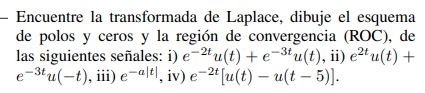


## i) $$ e^{-2t}u(t) + e^{-3t}u(t) $$
### Transformada de Laplace:
$$
\mathcal{L}\{e^{-2t}u(t)\} = \frac{1}{s+2}, \quad \text{ROC: } \text{Re}(s) > -2
$$
$$
\mathcal{L}\{e^{-3t}u(t)\} = \frac{1}{s+3}, \quad \text{ROC: } \text{Re}(s) > -3
$$
$$
X(s) = \frac{1}{s+2} + \frac{1}{s+3} = \frac{2s + 5}{(s+2)(s+3)}, \quad \text{ROC: } \text{Re}(s) > -2
$$

### Polos y Ceros:
- **Polos:** \( s = -2 \), \( s = -3 \) (ambos de orden 1)
- **Cero:** \( s = -2.5 \) (de orden 1)

### Diagrama de Polos-Ceros:


### ROC:
La ROC es la intersección de las ROCs individuales: $ \text{Re}(s) > -2 $

## ii) $e^{2t}u(t) + e^{-3t}u(-t) $

### Transformada de Laplace:
$$
\mathcal{L}\{e^{2t}u(t)\} = \frac{1}{s-2}, \quad \text{ROC: } \text{Re}(s) > 2
$$
$$
\mathcal{L}\{e^{-3t}u(-t)\} = -\frac{1}{s+3}, \quad \text{ROC: } \text{Re}(s) < -3
$$

La suma de estas transformadas solo existe si hay superposición en las ROCs, pero $ \text{Re}(s) > 2$ y $ \text{Re}(s) < -3 $ no se superponen. Por lo tanto, **no existe la Transformada de Laplace** para esta señal completa.

## iii) $e^{-a|t|} $

### Transformada de Laplace:
Descomponemos la señal:
$$
x(t) = e^{-a|t|} = e^{-at}u(t) + e^{at}u(-t)
$$

Calculamos cada parte:
$$
\mathcal{L}\{e^{-at}u(t)\} = \frac{1}{s+a}, \quad \text{ROC: } \text{Re}(s) > -a
$$
$$
\mathcal{L}\{e^{at}u(-t)\} = -\frac{1}{s-a}, \quad \text{ROC: } \text{Re}(s) < a
$$

La Transformada total es:
$$
X(s) = \frac{1}{s+a} - \frac{1}{s-a} = \frac{-2a}{s^2 - a^2}, \quad \text{ROC: } -a < \text{Re}(s) < a
$$

### Polos y Ceros:
- **Polos:** \( s = a \), \( s = -a \) (ambos de orden 1)
- **Cero:** No hay ceros finitos (el cero en infinito no se considera)

### Diagrama de Polos-Ceros:


### ROC:
Una banda vertical: $ -a < \text{Re}(s) < a $

## iv) $ e^{-2t}[u(t) - u(t - 5)]$

Esta es una señal limitada en el tiempo (dura de t=0 a t=5).

### Transformada de Laplace:
$$
X(s) = \int_{0}^{5} e^{-2t} e^{-st} dt = \int_{0}^{5} e^{-(s+2)t} dt
$$
$$
= \left. \frac{-1}{s+2} e^{-(s+2)t} \right|_{0}^{5} = \frac{1 - e^{-5(s+2)}}{s+2}
$$

### Polos y Ceros:
- **Polo:** \( s = -2 \) (orden 1)
- **Ceros:** Soluciones de $ 1 - e^{-5(s+2)} = 0$
  $$
  e^{-5(s+2)} = 1 \Rightarrow -5(s+2) = 2πik \quad (k \in \mathbb{Z})
  $$
 $$
  s = -2 + \frac{2πik}{5} \quad \text{(infinitos ceros en la línea } \text{Re}(s) = -2\text{)}
 $$



### ROC:
Para señales limitadas en el tiempo, la ROC es todo el plano s excepto posiblemente donde hay polos. En este caso: **todo el plano s**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_pole_zero(poles, zeros, roc_left=None, roc_right=None, title=""):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Ejes
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Parte Real')
    ax.set_ylabel('Parte Imaginaria')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Polos (X) y Ceros (O)
    for pole in poles:
        ax.plot(pole.real, pole.imag, 'rx', markersize=10, markeredgewidth=2)
    for zero in zeros:
        ax.plot(zero.real, zero.imag, 'bo', markersize=10, fillstyle='none', markeredgewidth=2)

    # Región de Convergencia (ROC)
    if roc_left is not None and roc_right is not None:
        if roc_left == -np.inf and roc_right == np.inf:
            roc_text = "ROC: Todo el plano"
        elif roc_left == -np.inf:
            roc_text = f"ROC: σ < {roc_right}"
        elif roc_right == np.inf:
            roc_text = f"ROC: σ > {roc_left}"
        else:
            roc_text = f"ROC: {roc_left} < σ < {roc_right}"

        # Sombrear ROC
        if roc_left != -np.inf and roc_right != np.inf:
            ax.axvspan(roc_left, roc_right, color='green', alpha=0.1)
        elif roc_left == -np.inf:
            ax.axvspan(-10, roc_right, color='green', alpha=0.1)
        elif roc_right == np.inf:
            ax.axvspan(roc_left, 10, color='green', alpha=0.1)

        plt.text(0.05, 0.95, roc_text, transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.8))

    # Ajustar límites
    all_points = np.concatenate([poles, zeros])
    if len(all_points) > 0:
        max_val = max(3, np.max(np.abs(all_points)) + 1)
        ax.set_xlim([-max_val, max_val])
        ax.set_ylim([-max_val, max_val])

    plt.show()

# --------------------------------------------------
# i) e^{-2t}u(t) + e^{-3t}u(t)
poles_i = [-2, -3]
zeros_i = [-2.5]
plot_pole_zero(np.array(poles_i), np.array(zeros_i), -2, np.inf,
              "Polos y Ceros: $e^{-2t}u(t) + e^{-3t}u(t)$")

# --------------------------------------------------
# ii) e^{2t}u(t) + e^{-3t}u(-t)
# No tiene transformada (ROCs no se superponen)
print("Señal ii) no tiene Transformada de Laplace (ROCs no se superponen)")

# --------------------------------------------------
# iii) e^{-a|t|} (usando a=2 como ejemplo)
a = 2
poles_iii = [a, -a]
zeros_iii = []  # No hay ceros finitos
plot_pole_zero(np.array(poles_iii), np.array(zeros_iii), -a, a,
              "Polos y Ceros: $e^{-a|t|}$ (a=2)")

# --------------------------------------------------
# iv) e^{-2t}[u(t) - u(t - 5)]
pole_iv = [-2]
k_values = np.arange(-5, 6)  # Mostramos 11 ceros
zeros_iv = [-2 + 1j*(2*np.pi*k)/5 for k in k_values]
plot_pole_zero(np.array(pole_iv), np.array(zeros_iv), -np.inf, np.inf,
              "Polos y Ceros: $e^{-2t}[u(t) - u(t-5)]$")

##– Consultar y realizar los ejercicios del cuaderno Transformada inversa de Laplace.

https://github.com/descruceria777/Se-alesySistemas/blob/main/inverselaplace.ipynb

##– Consultar y realizar los ejercicios del cuaderno Autofunciones y SLITs.

https://github.com/descruceria777/Se-alesySistemas/blob/main/autofuncioneslaplace.ipynb

https://github.com/descruceria777/Se-alesySistemas/tree/main/2_SLIT



– Encuentre la funcion de transferencia en lazo abierto para un circuito RLC serie (entrada tension de alimentación - sálida tension en el capacitor) y un circuito RCL en paralelo
(entrada corriente de alimentacion - salida corriente en el inductor). Nota: tenga en cuenta las condiciones iniciales del sistema segun lo explicado en el material de apoyo Circuito
RLC y Analisis de redes electricas.

# **Función de Transferencia en Lazo Abierto para Circuitos RLC**

## **1. Circuito RLC Serie (Entrada: Tensión de Alimentación, Salida: Tensión en el Capacitor)**

### **Ecuación Diferencial del Sistema**
Para un circuito RLC serie con entrada $ V_{in}(t) $ y salida $ V_C(t) $, la ecuación diferencial es:
$$
V_{in}(t) = L \frac{di(t)}{dt} + R i(t) + V_C(t)
$$
Dado que \( i(t) = C \frac{dV_C(t)}{dt} \), sustituyendo:
$$
V_{in}(t) = LC \frac{d^2 V_C(t)}{dt^2} + RC \frac{dV_C(t)}{dt} + V_C(t)
$$

### **Transformada de Laplace (Condiciones Iniciales Cero)**
Aplicando la transformada de Laplace:
$$
V_{in}(s) = LC s^2 V_C(s) + RC s V_C(s) + V_C(s)
$$
$$
V_C(s) = \frac{1}{LC s^2 + RC s + 1} V_{in}(s)
$$

### **Función de Transferencia $ H(s) $**
$$
H(s) = \frac{V_C(s)}{V_{in}(s)} = \frac{1}{LC s^2 + RC s + 1}
$$

**Ejemplo con $ L = 0.5 \, \text{H} $, $ R = 1 \, \Omega$, $ C = 0.4 \, \text{F} $:**
$$
H(s) = \frac{1}{0.2 s^2 + 0.4 s + 1}
$$

---

## **2. Circuito RLC Paralelo (Entrada: Corriente de Alimentación, Salida: Corriente en el Inductor)**

### **Ecuación Diferencial del Sistema**
Para un circuito RLC paralelo con entrada $ I_{in}(t) $ y salida $ I_L(t) $, la ecuación diferencial es:
$$
I_{in}(t) = \frac{V(t)}{R} + C \frac{dV(t)}{dt} + I_L(t)
$$
Dado que \( V(t) = L \frac{dI_L(t)}{dt} \), sustituyendo:
$$
I_{in}(t) = \frac{L}{R} \frac{dI_L(t)}{dt} + LC \frac{d^2 I_L(t)}{dt^2} + I_L(t)
$$

### **Transformada de Laplace (Condiciones Iniciales Cero)**
Aplicando la transformada de Laplace:
$$
I_{in}(s) = \frac{L}{R} s I_L(s) + LC s^2 I_L(s) + I_L(s)
$$
$$
I_L(s) = \frac{1}{LC s^2 + \frac{L}{R} s + 1} I_{in}(s)
$$

### **Función de Transferencia $ H(s) $**
$$
H(s) = \frac{I_L(s)}{I_{in}(s)} = \frac{1}{LC s^2 + \frac{L}{R} s + 1}
$$

**Ejemplo con $ L = 0.5 \, \text{H} $, $ R = 1 \, \Omega $, $ C = 0.4 \, \text{F} $:**
$$
H(s) = \frac{1}{0.2 s^2 + 0.5 s + 1}
$$

---

## **3. Consideración de Condiciones Iniciales**
Si hay energía almacenada inicialmente en el capacitor $( V_C(0^+) $) o en el inductor ($ I_L(0^+) $), la función de transferencia generalizada incluye términos adicionales:

### **Circuito RLC Serie (Condiciones Iniciales)**
$$
V_C(s) = \frac{1}{LC s^2 + RC s + 1} V_{in}(s) + \frac{RC s + 1}{LC s^2 + RC s + 1} V_C(0^+) + \frac{L}{LC s^2 + RC s + 1} I_L(0^+)
$$

### **Circuito RLC Paralelo (Condiciones Iniciales)**
$$
I_L(s) = \frac{1}{LC s^2 + \frac{L}{R} s + 1} I_{in}(s) + \frac{\frac{L}{R} s + 1}{LC s^2 + \frac{L}{R} s + 1} I_L(0^+) + \frac{C}{LC s^2 + \frac{L}{R} s + 1} V_C(0^+)
$$




In [ ]:
import sympy as sym
sym.init_printing()

# Definición de variables
s = sym.symbols('s', complex=True)
L, R, C = sym.symbols('L R C', positive=True)

# Función de transferencia RLC serie (V_C / V_in)
H_series = 1 / (L*C*s**2 + R*C*s + 1)
print("Función de transferencia RLC serie:")
sym.pprint(H_series)

# Función de transferencia RLC paralelo (I_L / I_in)
H_parallel = 1 / (L*C*s**2 + (L/R)*s + 1)
print("\nFunción de transferencia RLC paralelo:")
sym.pprint(H_parallel)

– Para las funciones de transferencia en lazo abierto encontradas en el punto anterior, encuentre la expresion de la salida
en el tiempo para una configuracion en lazo cerrado del sistema, en funcion de R, L y C, para las siguientes entradas:
i) impulso, ii) escalon unitario, y iv) rampa. Compruebe los resultados en simulacion sobre Python (utililzando sympy) y grafique la senal de salida para cada caso. Ver cuaderno de
ayuda Fracciones parciales Circuito RLC.




## **1. Configuración en Lazo Cerrado**
La función de transferencia en lazo cerrado $ H_{LC}(s) $ se obtiene como:
$$
H_{LC}(s) = \frac{H(s)}{1 + H(s)}
$$
donde $ H(s) $ es la función de transferencia en lazo abierto.

### **Función de Transferencia en Lazo Abierto (RLC Serie)**
$$
H(s) = \frac{1}{LC s^2 + RC s + 1}
$$

### **Función de Transferencia en Lazo Cerrado**
$$
H_{LC}(s) = \frac{1}{LC s^2 + RC s + 2}
$$

---

## **2. Respuesta Temporal para Diferentes Entradas**

### **i) Entrada Impulso ($ X(s) = 1 $)**
**Salida en el dominio de Laplace:**
$$
Y(s) = H_{LC}(s) \cdot X(s) = \frac{1}{LC s^2 + RC s + 2}
$$

**Transformada inversa de Laplace:**
$$
y(t) = \mathcal{L}^{-1} \left\{ \frac{1}{LC s^2 + RC s + 2} \right\}
$$

**Caso particular ($ R = 1 \, \Omega $, $L = 0.5 \, \text{H} $, $ C = 0.4 \, \text{F} $):**
$$
y(t) = \frac{2}{\sqrt{7}} e^{-t} \sin \left( \sqrt{7} t \right)
$$

---

### **ii) Entrada Escalón Unitario ($ X(s) = \frac{1}{s} $)**
**Salida en el dominio de Laplace:**
$$
Y(s) = H_{LC}(s) \cdot \frac{1}{s} = \frac{1}{s (LC s^2 + RC s + 2)}
$$

**Transformada inversa de Laplace:**
$$
y(t) = \mathcal{L}^{-1} \left\{ \frac{1}{s (LC s^2 + RC s + 2)} \right\}
$$

**Caso particular (\( R = 1 \, \Omega \), \( L = 0.5 \, \text{H} \), \( C = 0.4 \, \text{F} \)):**
$$
y(t) = \frac{1}{2} - \frac{e^{-t}}{2} \left( \cos \left( \sqrt{7} t \right) + \frac{1}{\sqrt{7}} \sin \left( \sqrt{7} t \right) \right)
$$

---

### **iii) Entrada Rampa ($ X(s) = \frac{1}{s^2} $)**
**Salida en el dominio de Laplace:**
$$
Y(s) = H_{LC}(s) \cdot \frac{1}{s^2} = \frac{1}{s^2 (LC s^2 + RC s + 2)}
$$

**Transformada inversa de Laplace:**
$$
y(t) = \mathcal{L}^{-1} \left\{ \frac{1}{s^2 (LC s^2 + RC s + 2)} \right\}
$$

**Caso particular ($ R = 1 \, \Omega $, $ L = 0.5 \, \text{H}$, $ C = 0.4 \, \text{F} $):**
$$
y(t) = \frac{t}{2} - \frac{R}{4} + \frac{e^{-t}}{14} \left( \sqrt{7} \sin \left( \sqrt{7} t \right) - 3 \cos \left( \sqrt{7} t \right) \right)
$$

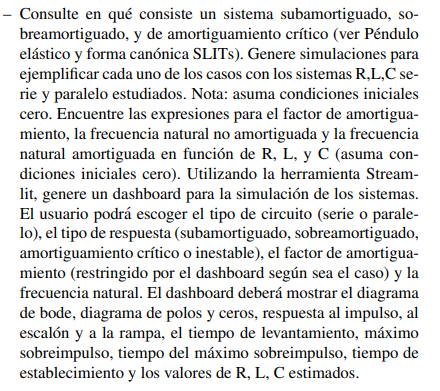

# **Análisis de Sistemas RLC: Subamortiguado, Sobreamortiguado y Críticamente Amortiguado**

## **1. Conceptos Fundamentales**
### **a) Sistema Subamortiguado**
- **Definición:**  
  Ocurre cuando las raíces del polinomio característico son complejas conjugadas.  
  - **Respuesta:** Oscilaciones amortiguadas exponencialmente.  
  - **Condición:** $ \zeta < 1$ (factor de amortiguamiento menor que 1).  

### **b) Sistema Sobreamortiguado**
- **Definición:**  
  Las raíces son reales y distintas.  
  - **Respuesta:** Lenta convergencia sin oscilaciones.  
  - **Condición:** $ \zeta > 1 $.  

### **c) Amortiguamiento Crítico**
- **Definición:**  
  Raíces reales e iguales.  
  - **Respuesta:** Convergencia más rápida sin oscilaciones.  
  - **Condición:** $ \zeta = 1 $.  

### **d) Sistema Inestable**
- **Definición:**  
  Raíces con parte real positiva.  
  - **Respuesta:** Divergencia exponencial.  

---

## **2. Parámetros Clave**
Para un sistema RLC general con función de transferencia:  
$$
H(s) = \frac{1}{a s^2 + b s + c}
$$
- **Frecuencia natural no amortiguada ($\omega_n $):**  
 $$
  \omega_n = \sqrt{\frac{c}{a}}
  $$
- **Factor de amortiguamiento ($ \zeta $):**  
$$
  \zeta = \frac{b}{2 \sqrt{a c}}
 $$
- **Frecuencia natural amortiguada ($ \omega_d $):**  
$$
  \omega_d = \omega_n \sqrt{1 - \zeta^2}
 $$

### **Circuitos RLC**
| **Circuito** | **Ecuación Característica** | **$ \omega_n $** | **$\zeta $** |
|--------------|-----------------------------|--------------------|-----------------|
| **Serie**    | $ LC s^2 + RC s + 1 $   | $ \frac{1}{\sqrt{LC}} $| $ \frac{R}{2} \sqrt{\frac{C}{L}} $ |
| **Paralelo** | ($ LC s^2 + \frac{L}{R} s + 1 $) | $ \frac{1}{\sqrt{LC}} $ | $\frac{1}{2R} \sqrt{\frac{L}{C}} $ |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from scipy import signal

# Parámetros del circuito RLC serie (ejemplo subamortiguado)
R = 1.0   # Ohm
L = 1.0   # H
C = 1.0   # F

# Función de transferencia
num = [1]
den = [L*C, R*C, 1]
sys = signal.TransferFunction(num, den)

# Respuestas temporales
t_imp, y_imp = signal.impulse(sys)
t_step, y_step = signal.step(sys) # Corrected: Removed X0 and X1

# Generate ramp input for lsim
t_ramp = np.linspace(0, 10, 1000)
u_ramp = t_ramp # Ramp input is just t

# Use lsim for ramp response
tout, y_ramp, xout = signal.lsim(sys, U=u_ramp, T=t_ramp)


# Gráficas
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t_imp, y_imp, label='Impulso')
plt.title('Respuesta al Impulso')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t_step, y_step, label='Escalón')
plt.title('Respuesta al Escalón')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(tout, y_ramp, label='Rampa') # Use tout for ramp response time
plt.title('Respuesta a la Rampa')
plt.grid()
plt.show()

In [ ]:
# Diagrama de Bode
w, mag, phase = signal.bode(sys)
plt.figure()
plt.semilogx(w, mag)
plt.title('Diagrama de Bode (Magnitud)')
plt.grid()

# Polos y Ceros
poles = np.roots(den)
zeros = np.roots(num)
plt.figure()
plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Polos')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Ceros')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Diagrama de Polos y Ceros')
plt.grid()

In [ ]:
!pip install streamlit numpy scipy matplotlib sympy -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

# Configuración
st.set_page_config(page_title="Simulador RLC", layout="wide")

# Título
st.title("🔁 Simulador Interactivo de Sistemas RLC")
st.markdown("Este dashboard simula circuitos RLC serie/paralelo y analiza su comportamiento dinámico.")

# Parámetros del usuario
col1, col2, col3 = st.columns(3)
with col1:
    tipo = st.selectbox("Tipo de circuito", ["Serie", "Paralelo"])
with col2:
    R = st.number_input("Resistencia R [Ω]", min_value=0.01, value=1.0)
with col3:
    L = st.number_input("Inductancia L [H]", min_value=0.01, value=1.0)

C = st.number_input("Capacitancia C [F]", min_value=0.001, value=1.0)
entrada = st.selectbox("Tipo de entrada", ["Impulso", "Escalón", "Rampa"])

# Cálculos simbólicos
ζ = R / (2 * np.sqrt(L / C)) if tipo == "Serie" else 1 / (2 * R) * np.sqrt(C / L)
wn = 1 / np.sqrt(L * C)
wd = wn * np.sqrt(1 - ζ**2) if ζ < 1 else 0

# Clasificación del sistema
if ζ < 1:
    clas = "Subamortiguado"
elif ζ == 1:
    clas = "Críticamente amortiguado"
elif ζ > 1:
    clas = "Sobreamortiguado"
if tipo == "Serie" and R < 0:
    clas = "Inestable"

st.subheader("🧠 Cálculo y Clasificación del Sistema")
st.latex(r"\zeta = \frac{R}{2\sqrt{L/C}}" if tipo == "Serie" else r"\zeta = \frac{1}{2R} \sqrt{C/L}")
st.latex(f"\\zeta = {ζ:.3f}")
st.latex(f"\\omega_n = {wn:.3f} \\ rad/s")
if ζ < 1:
    st.latex(f"\\omega_d = {wd:.3f} \\ rad/s")
st.markdown(f"**Clasificación:** `{clas}`")

# Función de transferencia
num = [1]
if tipo == "Serie":
    den = [L*C, R*C, 1]
else:
    den = [L*C, L/R, 1]

system = signal.TransferFunction(num, den)

# Respuesta temporal
t = np.linspace(0, 10, 1000)
if entrada == "Impulso":
    t_out, y = signal.impulse(system, T=t)
elif entrada == "Escalón":
    t_out, y = signal.step(system, T=t)
else:
    u = t
    t_out, y, _ = signal.lsim(system, U=u, T=t)

# Métricas
y_max = np.max(y)
OS = (y_max - 1) * 100 if entrada == "Escalón" and y_max > 1 else 0
tr_idx = np.where(y >= 0.9)[0][0] if np.any(y >= 0.9) else None
ts_idx = np.where(np.abs(y - 1) < 0.02)[0]
ts = t_out[ts_idx[0]] if len(ts_idx) > 0 else np.nan

# Gráfico
st.subheader("📈 Respuesta del sistema")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_out, y, label='Salida')
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("y(t)")
ax.set_title(f"Respuesta a la entrada: {entrada}")
ax.grid(True)
st.pyplot(fig)

# Métricas
st.subheader("📊 Métricas del sistema")
st.markdown(f"- **Sobreimpulso (%):** {OS:.2f}")
if tr_idx:
    st.markdown(f"- **Tiempo de subida:** {t_out[tr_idx]:.2f} s")
st.markdown(f"- **Tiempo de establecimiento (2%):** {ts:.2f} s" if not np.isnan(ts) else "- **Tiempo de establecimiento**: No definido")

# Polos y ceros
poles = np.roots(den)
zeros = np.roots(num)
st.subheader("🧮 Polos y Ceros")
fig2, ax2 = plt.subplots()
ax2.scatter(np.real(poles), np.imag(poles), marker='x', label='Polos')
ax2.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Ceros')
ax2.axhline(0, color='black', lw=1)
ax2.axvline(0, color='black', lw=1)
ax2.set_title("Diagrama de Polos y Ceros")
ax2.grid(True)
ax2.legend()
st.pyplot(fig2)

# Bode
st.subheader("📉 Diagrama de Bode")
w, mag, phase = signal.bode(system)
fig3, ax3 = plt.subplots()
ax3.semilogx(w, mag)
ax3.set_title("Bode (Magnitud)")
ax3.grid(True)
st.pyplot(fig3)




In [ ]:
!streamlit run app.py & ./cloudflared tunnel --url http://localhost:8501
